# Phase 4: Model Tuning & Tracking

In this notebook, we introduce **Optuna** for hyperparameter tuning and **MLflow** for tracking our trainings and later comapre the results to other model training results like the neural network and so on. 


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import mlflow
import sys
from sklearn.model_selection import StratifiedKFold

sys.path.append('../')
from src.metrics import zindi_score

# setup MLflow
# mlflow.set_tracking_uri('sqlite:///../mlflow.db')
# mlflow.set_experiment('Zindi_Liquidity_Stress')

# Load Data
train_df = pd.read_parquet('../data/features/train_features.parquet', engine='fastparquet')
raw_train = pd.read_csv('../data/Train.csv')
target = raw_train['liquidity_stress_next_30d']

X = train_df.drop(columns=['ID', 'liquidity_stress_next_30d'])
print(f"Data loaded for tuning: {X.shape}")

/Users/USER/Desktop/zindi/ml_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded for tuning: (40000, 228)


> **Note on MLflow Tracking:** 
> We have a db for logging the parameters and the results of the training every time Optuna tests a new set of hyperparameters.

In [2]:
# define the Optuna Objective Function
def objective(trial):
    param = {
        'objective': 'binary', # predicting two classes either stress or no stress
        'metric': 'binary_logloss', # the main penalty metric of the competition
        'verbosity': -1, # silences LightGBM warnings to keep the tuning logs clean
        'boosting_type': 'gbdt', # Standard Gradient Boosting Decision Tree, most stable
        'n_estimators': 300, # fixed number of trees, set such that it is high enough to learn, low enough to prevent massive overfitting
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100), # maximum leaves per tree, 20-100 balances model complexity to memory/overfitting
        'max_depth': trial.suggest_int('max_depth', 4, 12), # maximum tree depth, 4-12 captures any complex interactions without memorizing the training data
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 150), # minimum data points per leaf, 20-150 prevents the model from learning from tiny, noisy subsets
        'subsample': trial.suggest_float('subsample', 0.6, 1.0), # the fraction of rows used per tree, 0.6-1.0 introduces randomness to prevent overfitting
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0) # the fraction of columns used per tree; 0.6-1.0 forces the trees to learn from different features
    }
    
    # 5-Fold CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, target)):
        X_train, y_train = X.iloc[train_idx], target.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], target.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**param)
        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        
    # calculate the Zindi metrics, logloss and roc-auc
    loss, auc = zindi_score(target, oof_preds)
    
    # log to MLflow for every trial
    # with mlflow.start_run(nested=True):
    #     mlflow.log_params(param)
    #     mlflow.log_metric('cv_logloss', loss)
    #     mlflow.log_metric('cv_auc', auc)
        
    # Optuna to minimize Log Loss
    return loss

In [3]:
print("Starting Optuna Hyperparameter Tuning...")

# create an MLflow run to group these trials
with mlflow.start_run(run_name='LightGBM_Optuna_Tuning'):
    study = optuna.create_study(direction='minimize')
    # run for 10 trials
    study.optimize(objective, n_trials=10)

print("Tuning finished!")
print(f"Best LogLoss: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Starting Optuna Hyperparameter Tuning...


2026/09/01 04:03:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/01 04:03:52 INFO mlflow.store.db.utils: Updating database tables
[I 2026-09-01 04:03:53,340] A new study created in memory with name: no-name-70177a16-e797-468e-b5a7-3c583b8efeb8
[I 2026-09-01 04:04:02,016] Trial 0 finished with value: 0.32766311856390695 and parameters: {'learning_rate': 0.014442709445834747, 'num_leaves': 97, 'max_depth': 4, 'min_child_samples': 26, 'subsample': 0.7542910003905335, 'colsample_bytree': 0.7928839636636574}. Best is trial 0 with value: 0.32766311856390695.


--- Model Evaluation ---
Log Loss: 0.3277
ROC-AUC: 0.8406
------------------------


[I 2026-09-01 04:04:13,707] Trial 1 finished with value: 0.2789812544837798 and parameters: {'learning_rate': 0.047969258972561005, 'num_leaves': 34, 'max_depth': 5, 'min_child_samples': 32, 'subsample': 0.9795778949021702, 'colsample_bytree': 0.8992303287136993}. Best is trial 1 with value: 0.2789812544837798.


--- Model Evaluation ---
Log Loss: 0.2790
ROC-AUC: 0.8824
------------------------


...

--- Model Evaluation ---
Log Loss: 0.2734
ROC-AUC: 0.8887
------------------------


[I 2026-09-01 04:06:26,056] Trial 8 finished with value: 0.30144411239859925 and parameters: {'learning_rate': 0.030360364948850745, 'num_leaves': 40, 'max_depth': 4, 'min_child_samples': 117, 'subsample': 0.6884472863380305, 'colsample_bytree': 0.6682704306726556}. Best is trial 6 with value: 0.27153263209738815.


--- Model Evaluation ---
Log Loss: 0.3014
ROC-AUC: 0.8653
------------------------


[I 2026-09-01 04:06:49,028] Trial 9 finished with value: 0.27798357114544847 and parameters: {'learning_rate': 0.02628162489629256, 'num_leaves': 51, 'max_depth': 8, 'min_child_samples': 28, 'subsample': 0.7086193049494851, 'colsample_bytree': 0.6108168106671421}. Best is trial 6 with value: 0.27153263209738815.


--- Model Evaluation ---
Log Loss: 0.2780
ROC-AUC: 0.8859
------------------------
Tuning finished!
Best LogLoss: 0.2715
Best Parameters:
  learning_rate: 0.04172179543640608
  num_leaves: 53
  max_depth: 8
  min_child_samples: 20
  subsample: 0.7321824821034763
  colsample_bytree: 0.9703330417113939


In [5]:
print("Training Best Model for Overfitting Check...")
best_params = study.best_params.copy()
best_params['objective'] = 'binary'
best_params['metric'] = 'binary_logloss'
best_params['verbosity'] = -1
best_params['boosting_type'] = 'gbdt'
best_params['n_estimators'] = 300
best_params['random_state'] = 42

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, target, test_size=0.2, random_state=42, stratify=target)

model_lgb = lgb.LGBMClassifier(**best_params)
model_lgb.fit(X_train, y_train)
print("Best model trained and saved to memory as `model_lgb`.")

Training Best Model for Overfitting Check...
Best model trained and saved to memory as `model_lgb`.


## Overfitting Check

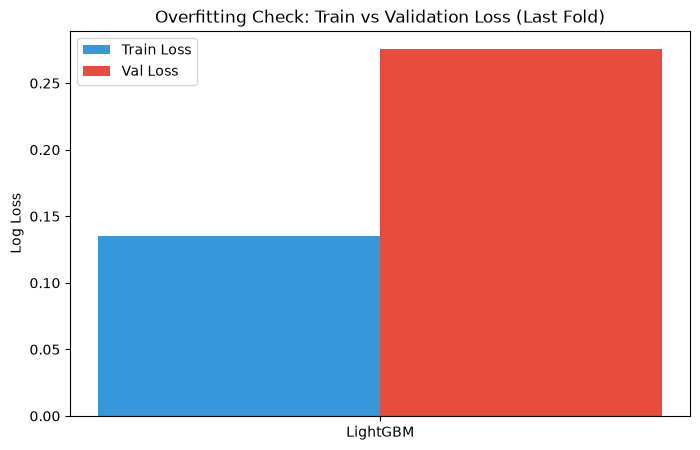

LightGBM - Train: 0.1355, Val: 0.2755, Gap: 0.1399


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

def check_overfitting():
    try:
        models_to_check = {}
        if 'model_lgb' in globals(): models_to_check['LightGBM'] = model_lgb
        # if 'model_cb' in globals(): models_to_check['CatBoost'] = model_cb
        # if 'model_xgb' in globals(): models_to_check['XGBoost'] = model_xgb
        # if 'model' in globals() and 'LGBM' in str(type(model)): models_to_check['LightGBM'] = model
        
        if not models_to_check:
            print("No standard models found in memory to check.")
            return
            
        if 'X_train' not in globals() or 'X_val' not in globals():
            print("X_train or X_val not found in memory.")
            return
            
        train_losses = []
        val_losses = []
        names = []
        
        for name, m in models_to_check.items():
            train_p = m.predict_proba(X_train)[:, 1]
            val_p = m.predict_proba(X_val)[:, 1]
            train_losses.append(log_loss(y_train, train_p))
            val_losses.append(log_loss(y_val, val_p))
            names.append(name)
            
        x = range(len(names))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar([i - width/2 for i in x], train_losses, width, label='Train Loss', color='#3498db')
        ax.bar([i + width/2 for i in x], val_losses, width, label='Val Loss', color='#e74c3c')
        
        ax.set_ylabel('Log Loss')
        ax.set_title('Overfitting Check: Train vs Validation Loss (Last Fold)')
        ax.set_xticks(x)
        ax.set_xticklabels(names)
        ax.legend()
        plt.show()
        
        for i, name in enumerate(names):
            print(f"{name} - Train: {train_losses[i]:.4f}, Val: {val_losses[i]:.4f}, Gap: {val_losses[i] - train_losses[i]:.4f}")
            
    except Exception as e:
        print(f"Could not run overfitting check: {e}")

check_overfitting()